In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from lightgbm import LGBMClassifier
from fairlearn.metrics import (
    MetricFrame, selection_rate, false_positive_rate, false_negative_rate
)

from src.features import build_features

X, y = build_features()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
for col in categorical_features:
    X[col] = X[col].astype('category')

In [2]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full, y_train_full, test_size=0.25, stratify=y_train_full, random_state=42)

model = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                       class_weight='balanced', random_state=42, verbose=-1)
model.fit(X_train, y_train)

calibrated = CalibratedClassifierCV(FrozenEstimator(model), method='isotonic')
calibrated.fit(X_cal, y_cal)

y_prob = calibrated.predict_proba(X_test)[:, 1]
print(f"AUC:   {roc_auc_score(y_test, y_prob):.3f}")
print(f"Brier: {brier_score_loss(y_test, y_prob):.4f}")

AUC:   0.767
Brier: 0.0671


In [3]:
gender = X_test['CODE_GENDER'].astype(str)

age_years = -X_test['DAYS_BIRTH'] / 365.25
age_group = pd.cut(age_years, bins=[0, 30, 40, 50, 60, 200],
                   labels=['<30', '30-40', '40-50', '50-60', '60+'])

print(gender.value_counts(), '\n')
print(age_group.value_counts().sort_index())

CODE_GENDER
F      40561
M      20940
XNA        2
Name: count, dtype: int64 

DAYS_BIRTH
<30       8905
30-40    16491
40-50    15299
50-60    13620
60+       7188
Name: count, dtype: int64


In [4]:
THRESHOLD = 0.15
y_pred = (y_prob >= THRESHOLD).astype(int)

print(f"Threshold: {THRESHOLD}")
print(f"Overall rejection rate: {y_pred.mean():.3f}")
print(f"Actual default rate:    {y_test.mean():.3f}")

Threshold: 0.15
Overall rejection rate: 0.163
Actual default rate:    0.081


In [5]:
metrics = {
    'selection_rate': selection_rate,
    'false_positive_rate': false_positive_rate,
    'false_negative_rate': false_negative_rate,
}

mf_gender = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred,
                        sensitive_features=gender)
mf_age = MetricFrame(metrics=metrics, y_true=y_test, y_pred=y_pred,
                     sensitive_features=age_group)

print("By gender\n", mf_gender.by_group, '\n')
print("Differences\n", mf_gender.difference(), '\n')
print("By age\n", mf_age.by_group, '\n')
print("Differences\n", mf_age.difference())

By gender
              selection_rate  false_positive_rate  false_negative_rate
CODE_GENDER                                                          
F                  0.128769             0.106826             0.579337
M                  0.227985             0.190739             0.442931
XNA                0.000000             0.000000             0.000000 

Differences
 selection_rate         0.227985
false_positive_rate    0.190739
false_negative_rate    0.579337
dtype: float64 

By age
             selection_rate  false_positive_rate  false_negative_rate
DAYS_BIRTH                                                          
30-40             0.204718             0.168779             0.455640
40-50             0.149879             0.124337             0.538793
50-60             0.099780             0.082941             0.651620
60+               0.054396             0.045381             0.773109
<30               0.289500             0.250032             0.400596 

Differences
 selec

In [6]:
def auc_by_group(scores, labels, groups):
    out = {}
    for g in groups.unique():
        mask = groups == g
        if mask.sum() > 100 and labels[mask].nunique() > 1:
            out[g] = roc_auc_score(labels[mask], scores[mask])
    return pd.Series(out).sort_index()

print("AUC by gender\n", auc_by_group(y_prob, y_test, gender), '\n')
print("AUC by age\n", auc_by_group(y_prob, y_test, age_group))

AUC by gender
 F    0.758484
M    0.767270
dtype: float64 

AUC by age
 30-40    0.770893
40-50    0.764088
50-60    0.751884
60+      0.727039
<30      0.745541
dtype: float64


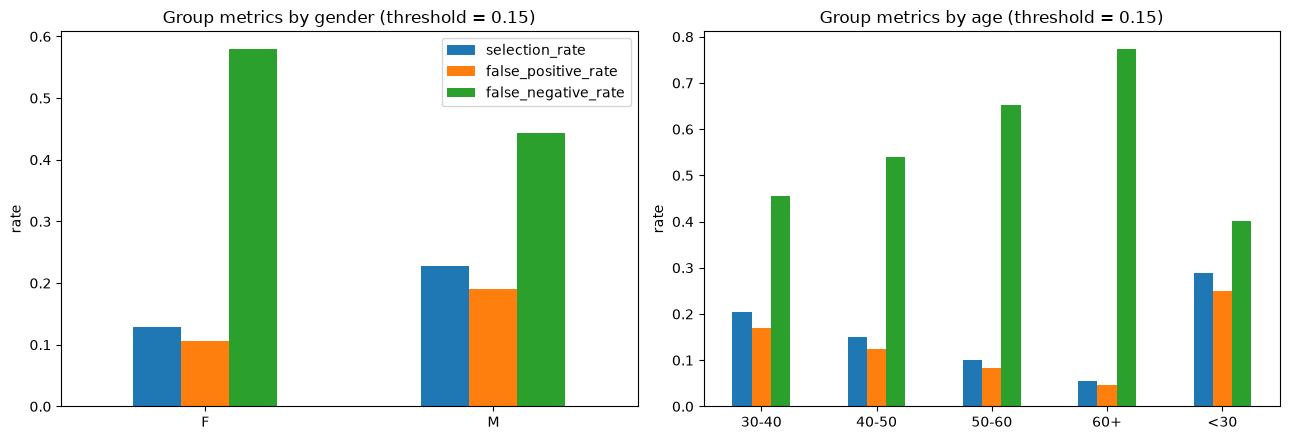

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mf_gender.by_group.loc[['F', 'M']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title(f'Group metrics by gender (threshold = {THRESHOLD})')
axes[0].set_xlabel('')
axes[0].set_ylabel('rate')

mf_age.by_group.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title(f'Group metrics by age (threshold = {THRESHOLD})')
axes[1].set_xlabel('')
axes[1].set_ylabel('rate')
axes[1].legend().remove()

plt.tight_layout()
plt.savefig('../reports/fairness.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
base_rates = pd.DataFrame({
    'n': y_test.groupby(gender).size(),
    'default_rate': y_test.groupby(gender).mean(),
    'selection_rate': mf_gender.by_group['selection_rate'],
})
print(base_rates, '\n')

base_rates_age = pd.DataFrame({
    'n': y_test.groupby(age_group, observed=True).size(),
    'default_rate': y_test.groupby(age_group, observed=True).mean(),
    'selection_rate': mf_age.by_group['selection_rate'],
})
print(base_rates_age)

                 n  default_rate  selection_rate
CODE_GENDER                                     
F            40561      0.069919        0.128769
M            20940      0.101671        0.227985
XNA              2      0.000000        0.000000 

                n  default_rate  selection_rate
DAYS_BIRTH                                     
30-40       16491      0.095689        0.204718
40-50       15299      0.075822        0.149879
50-60       13620      0.063436        0.099780
60+          7188      0.049666        0.054396
<30          8905      0.112970        0.289500


# Credit Default Prediction

Predicting loan default risk on the Home Credit dataset, with a focus on
probability calibration and model explainability — not just maximum AUC.

## Motivation

Machine learning is no longer something only software engineers need to
understand. As an electrical engineer, even extending to all engineers, it has become too central to the systems I
work on, and to daily life, to treat as someone else's specialism. I took a
course on Artificial Intelligence during my bachelor's, covering neural networks
and reinforcement learning, and this project is where I refresh that foundation
and extend it with the parts a course does not cover: real data, real class
imbalance, and the decisions that come after a model produces a number.

I deliberately chose a domain my engineering programme never touched. Credit
risk sits in the financial sector, it has consequences for the people it scores,
and it is regulated — which makes it a better teacher than another signal
processing problem would have been.

A credit risk model that only ranks applicants is not enough. A bank prices
loans using expected loss, which requires probabilities that mean what they
say. It has to justify rejections to customers and to regulators, which
requires per-decision explanations. And it has to demonstrate that the model
performs fairly across demographic groups.

This project builds a default prediction model end to end with those
constraints treated as first-class requirements rather than afterthoughts.

## Dataset

[Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk):
307,511 loan applications across seven tables, covering the current
application, prior applications with Home Credit, and credit history reported
by other institutions. Target: whether the client had payment difficulties.
Base default rate is 8.1%.

## Results

Each step is measured against the previous one, so the contribution of every
addition is visible:

| Step | Features | Model | AUC-ROC |
|------|----------|-------|---------|
| 1 | 10 numeric main-table columns | Logistic regression | 0.62 |
| 2 | + all categorical columns | Logistic regression | 0.66 |
| 3 | + all main-table features | Logistic regression | 0.XX |
| 4 | + bureau aggregations | Logistic regression | 0.XX |
| 5 | + previous_application aggregations | Logistic regression | 0.73 |
| 6 | same features | LightGBM | **0.77** |

AUC-PR on the final model is 0.26, against a random baseline of 0.08.

The logistic regression baseline is not decoration. Without it, an AUC of 0.77
is a number with no reference point; with it, the 0.04 gain from switching to
gradient boosting is a measured result that justifies the added complexity.

## Calibration

![Reliability diagram](reports/calibration.png)

The raw LightGBM output is severely miscalibrated. At a predicted probability
of 0.75, the observed default rate is only about 0.24. The cause is
`class_weight="balanced"`, which up-weights the minority class during training
and inflates output probabilities far above the true 8% base rate. This helps
ranking but makes the scores unusable as probabilities.

The Brier score quantifies the problem. Predicting the base rate of 0.08 for
every client scores about 0.074, so the uncalibrated model at **0.16 performs
worse than a constant prediction** in probabilistic terms, despite its AUC of
0.77. After isotonic calibration on a held-out calibration set the Brier score
falls to **0.065**, below the constant baseline, while AUC is unchanged —
isotonic regression is monotonic, so it re-maps values without altering the
ranking.

## Explainability

![SHAP summary](reports/shap_summary.png)

The three `EXT_SOURCE` features — normalised scores from external credit
bureaus — dominate the model. Their direction is as expected: higher external
scores push predictions towards lower risk.

Three of the aggregated features built in `src/features.py` rank in the top
fifteen, indicating that the multi-table feature engineering added genuine
signal:

- **`prev_credit_vs_application`** (rank 4) — clients who previously received
  less credit than they applied for are predicted as higher risk.
- **`bureau_debt_credit_ratio`** (rank 8) — a higher share of outstanding debt
  relative to total credit increases predicted risk.
- **`prev_refusal_rate`** (rank 14) — a history of refused applications
  increases predicted risk.

`CODE_GENDER` also appears among the top features and contributes materially
to individual predictions. A model that uses gender as a predictor requires
explicit fairness assessment before deployment could be considered — group-wise
performance and error rates need to be measured, not assumed. This is the
motivation for the fairness analysis below.

## Fairness

![Group metrics](reports/fairness.png)

Every number here follows from one choice: a decision threshold of 0.15 on the
calibrated probability, giving an overall rejection rate of 16.3% against a true
default rate of 8.1%. That threshold is a business decision, not a property of the
model, and every disparity below scales with it.

| Group | n | True default rate | Rejection rate | FPR | FNR | AUC |
|-------|---|-------------------|----------------|-----|-----|-----|
| Female | 40,561 | 0.070 | 0.129 | 0.107 | 0.579 | 0.758 |
| Male | 20,940 | 0.102 | 0.228 | 0.191 | 0.443 | 0.767 |
| Age <30 | 8,905 | 0.113 | 0.290 | 0.250 | 0.401 | 0.746 |
| Age 30–40 | 16,491 | 0.096 | 0.205 | 0.169 | 0.456 | 0.771 |
| Age 40–50 | 15,299 | 0.076 | 0.150 | 0.124 | 0.539 | 0.764 |
| Age 50–60 | 13,620 | 0.063 | 0.100 | 0.083 | 0.652 | 0.752 |
| Age 60+ | 7,188 | 0.050 | 0.054 | 0.045 | 0.773 | 0.727 |

A third gender category holds two clients and supports no conclusion; because
Fairlearn computes `difference()` against the smallest group, the reported
aggregate gender differences are not the male–female gaps discussed here.

**The rejection gap is larger than the risk gap.** True default rates do differ
between groups, but the model amplifies those differences rather than tracking
them:

| Comparison | Ratio of true default rates | Ratio of rejection rates |
|------------|-----------------------------|--------------------------|
| Male vs female | 10.2% / 7.0% = 1.45 | 22.8% / 12.9% = 1.77 |
| Age <30 vs 60+ | 11.3% / 5.0% = 2.27 | 29.0% / 5.4% = 5.32 |

The same effect read down the age column: every group is rejected more often than
its own default rate, but the multiple falls monotonically from 2.6× for the
under-30s to 1.1× for the over-60s. Young applicants absorb the threshold, older
ones barely feel it — which is why the FNR at 60+ reaches 0.773 and the model
waves through more than three in four defaulters in that group.

This is not a defect to be patched. A fixed threshold on a monotone score
necessarily amplifies base-rate differences, because it cuts into the tail of the
score distribution, where a small shift in the group mean moves a large share of
the mass across the cut.

**The disparity is in outcomes, not in model quality.** AUC stays within
0.727–0.771 across every group, so the model separates defaulters from
non-defaulters about equally well everywhere. The unequal rejection rates come
from groups sitting at different points of the same score distribution under one
global threshold.

**Equal selection rates and equal error rates cannot both hold.** Across age
groups FPR falls from 0.250 to 0.045 while FNR rises from 0.401 to 0.773: groups
rejected more often absorb more false rejections and fewer missed defaults. When
true default rates differ between groups, no single threshold equalises selection
rate, false positive rate and false negative rate simultaneously. Which one to
equalise is a policy decision that determines who bears the cost of the model's
errors.

Before deployment this model would need `CODE_GENDER` removed and the cost in AUC
measured, group metrics reported across a range of thresholds rather than one,
and any fairness constraint applied explicitly — with a stated definition —
rather than left implicit.

## Method notes

- **Split before exploring.** The test set is held out before any EDA or
  feature selection, and touched only for final evaluation.
- **Preprocessing inside the pipeline.** Imputation and scaling statistics are
  learned on training data only and applied unchanged to the test set, making
  leakage through preprocessing structurally impossible.
- **Three-way split for calibration.** The calibration mapping is fitted on a
  separate held-out set the model never saw during training.
- **Aggregation before joining.** The auxiliary tables hold multiple rows per
  client, summarised to one row per client using counts, sums, means, maxima
  and derived ratios before merging.

## Structure

```
credit-default-prediction/
├── data/                         # not tracked — download from Kaggle
├── notebooks/
│   ├── 01_baseline.ipynb
│   ├── 02_categorical.ipynb
│   ├── 03_all_main_features.ipynb
│   ├── 04_bureau_features.ipynb
│   ├── 05_previous_app_features.ipynb
│   ├── 06_lightgbm.ipynb
│   ├── 07_calibration_shap.ipynb
│   └── 08_fairness.ipynb
├── src/
│   └── features.py               # multi-table aggregation and feature assembly
├── reports/                      # figures
└── README.md
```

## Reproducing

```bash
conda create -n credit python=3.11
conda activate credit
pip install pandas numpy scikit-learn matplotlib seaborn jupyter lightgbm shap fairlearn
```

Download the competition data and unzip it into `data/`, then run the
notebooks in order.

## Planned work

- Cross-validated error bars instead of single-split point estimates
- A reproducible training script (`train.py`) reproducing the final model from
  the command line

## Author

Francisak Prusov — MSc Electrical Engineering, Ghent University (2026).
Built as a self-directed project while moving into applied machine learning.
